In [129]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from dotenv import load_dotenv, find_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing import Any
import requests
import math
import os

In [130]:
load_dotenv(find_dotenv())

True

In [131]:
llm = ChatGroq(
    model="openai/gpt-oss-20b"
)

In [ ]:
import os

os.environ["TAVILY_API_KEY"] 

In [133]:
# Tools
search_tool = TavilySearch(
    max_results=5,
    topic="general",
    search_depth="advanced"
)



@tool
def calculator(expression: str) -> str:
    """
    Useful for simple math calculations.
    Input should be a valid math expression.
    Example: 2 + 2, math.sqrt(16), 10 * 5
    """

    try:
        allowed = {
            "math": math,
            "abs": abs,
            "round": round,
            "min": min,
            "max": max,
            "sum": sum
        }

        result = eval(expression, {"__builtins__": {}}, allowed)
        return str(result)

    except Exception as e:
        return f"Calculation error: {str(e)}"


@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=KAMZTGME5XBVGP37"
    r = requests.get(url)
    return r.json()



@tool
def get_current_weather(location: str) -> str:
    """
    Get the current real-time weather for a given city or location.

    Args:
        location: City or location name, for example:
                  "Ambala", "London, UK", or "New York, US".

    Returns:
        A formatted current weather report.
    """

    api_key = os.getenv("OPENWEATHER_API_KEY")

    if not api_key:
        return (
            "Weather API key is missing. "
            "Set the OPENWEATHER_API_KEY environment variable."
        )

    try:
        # Step 1: Convert the location name into latitude and longitude
        geocoding_url = "https://api.openweathermap.org/geo/1.0/direct"

        geocoding_params = {
            "q": location,
            "limit": 1,
            "appid": api_key,
        }

        geo_response = requests.get(
            geocoding_url,
            params=geocoding_params,
            timeout=10,
        )
        geo_response.raise_for_status()

        locations: list[dict[str, Any]] = geo_response.json()

        if not locations:
            return f"Could not find the location: {location}"

        latitude = locations[0]["lat"]
        longitude = locations[0]["lon"]
        resolved_name = locations[0].get("name", location)
        country = locations[0].get("country", "")
        state = locations[0].get("state", "")

        # Step 2: Get current weather using latitude and longitude
        weather_url = "https://api.openweathermap.org/data/2.5/weather"

        weather_params = {
            "lat": latitude,
            "lon": longitude,
            "appid": api_key,
            "units": "metric",
        }

        weather_response = requests.get(
            weather_url,
            params=weather_params,
            timeout=10,
        )
        weather_response.raise_for_status()

        weather_data = weather_response.json()

        temperature = weather_data["main"]["temp"]
        feels_like = weather_data["main"]["feels_like"]
        humidity = weather_data["main"]["humidity"]
        pressure = weather_data["main"]["pressure"]
        description = weather_data["weather"][0]["description"]
        wind_speed = weather_data.get("wind", {}).get("speed", "N/A")
        visibility_meters = weather_data.get("visibility")

        visibility_km = (
            round(visibility_meters / 1000, 1)
            if visibility_meters is not None
            else "N/A"
        )

        location_parts = [resolved_name]

        if state:
            location_parts.append(state)

        if country:
            location_parts.append(country)

        display_location = ", ".join(location_parts)

        return (
            f"Current weather in {display_location}:\n"
            f"- Condition: {description.title()}\n"
            f"- Temperature: {temperature}°C\n"
            f"- Feels like: {feels_like}°C\n"
            f"- Humidity: {humidity}%\n"
            f"- Pressure: {pressure} hPa\n"
            f"- Wind speed: {wind_speed} m/s\n"
            f"- Visibility: {visibility_km} km"
        )

    except requests.Timeout:
        return "The weather service request timed out. Please try again."

    except requests.HTTPError as error:
        status_code = error.response.status_code if error.response else "unknown"

        if status_code == 401:
            return "The OpenWeather API key is invalid or inactive."

        return f"Weather API returned an HTTP error: {status_code}"

    except requests.RequestException as error:
        return f"Could not connect to the weather service: {error}"

    except (KeyError, TypeError, ValueError) as error:
        return f"Unexpected weather API response: {error}"

In [134]:
# Make tool list
tools = [search_tool, calculator, get_stock_price,get_current_weather]

# Make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

In [135]:
# state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [136]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

In [137]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [138]:
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")    

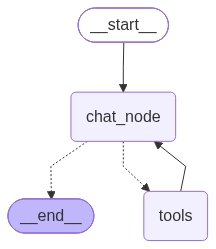

In [139]:
chatbot = graph.compile()

chatbot

In [140]:
# Regular chat
out = chatbot.invoke({"messages": [HumanMessage(content="Hello!")]})

print(out["messages"][-1].content)


Hello! How can I help you today?


In [111]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is 8*9+5?")]})
print(out["messages"][-1].content)

The result of \(8 \times 9 + 5\) is **77**.


In [142]:
out = chatbot.invoke({
    "messages": [HumanMessage(content="what is the new movie releases in 2026")]
})
print(out["messages"][-1].content)

Here’s a quick snapshot of the most talked‑about releases slated for 2026. (All dates are U.S. theatrical releases; some titles may also hit streaming platforms or other regions around the same time.)

| Month | Notable Releases | Genre Highlights |
|-------|------------------|------------------|
| **January** | *The Pride of Bharat: Chhatrapati Shivaji Maharaj* – biopic; *Love & War* – romantic drama | Historical drama, romance |
| **February** | *Ice Age: Boiling Point* – animated adventure; *Naagzilla* – action‑horror | Family, monster‑action |
| **March** | *Project Hail Mary* – sci‑fi drama; *War Machine* – action‑comedy | Sci‑fi, action |
| **April** | *Primitive War* – war drama; *A Great Awakening* – thriller | War, thriller |
| **May** | *The Dog Stars* – drama‑adventure | Drama, adventure |
| **June** | *Spider‑Man: Brand New Day* – superhero; *Jumanji: Open World* – action‑adventure | Superhero, adventure |
| **July** | *Runner* – action thriller; *Insidious: Out of the Furt

In [143]:
for msg in out["messages"]:
    print("=" * 60)
    print(type(msg).__name__)
    print(msg)

HumanMessage
content='what is the new movie releases in 2026' additional_kwargs={} response_metadata={} id='f7167e22-b7ed-4087-b2a2-841be1de7fa5'
AIMessage
content='' additional_kwargs={'reasoning_content': 'User asks: "what is the new movie releases in 2026". We need to provide answer. It\'s a future event. We might need up-to-date info. We could search. Use tavily_search to get current releases.', 'tool_calls': [{'id': 'fc_93e2ed19-1b82-408d-83cc-64326951bcda', 'function': {'arguments': '{"query":"2026 new movie releases 2026 upcoming movies","search_depth":"advanced","topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 101, 'prompt_tokens': 492, 'total_tokens': 593, 'completion_time': 0.179353724, 'completion_tokens_details': {'reasoning_tokens': 48}, 'prompt_time': 0.023991128, 'prompt_tokens_details': None, 'queue_time': 0.049215471, 'total_time': 0.203344852}, 'model_name': 'openai/gpt-oss-20b', 'system_finge

In [144]:
print(repr(out["messages"][-1].content))

'Here’s a quick snapshot of the most talked‑about releases slated for 2026. (All dates are U.S. theatrical releases; some titles may also hit streaming platforms or other regions around the same time.)\n\n| Month | Notable Releases | Genre Highlights |\n|-------|------------------|------------------|\n| **January** | *The Pride of Bharat: Chhatrapati Shivaji Maharaj* – biopic; *Love & War* – romantic drama | Historical drama, romance |\n| **February** | *Ice Age: Boiling Point* – animated adventure; *Naagzilla* – action‑horror | Family, monster‑action |\n| **March** | *Project Hail\u202fMary* – sci‑fi drama; *War Machine* – action‑comedy | Sci‑fi, action |\n| **April** | *Primitive War* – war drama; *A Great Awakening* – thriller | War, thriller |\n| **May** | *The Dog Stars* – drama‑adventure | Drama, adventure |\n| **June** | *Spider‑Man: Brand New Day* – superhero; *Jumanji: Open World* – action‑adventure | Superhero, adventure |\n| **July** | *Runner* – action thriller; *Insidious:

In [145]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="First find out the stock price of Microsoft using get stock price tool then use the calculator tool to find out how much will it take to purchase 50 shares?")]})
print(out["messages"][-1].content)

**Microsoft (MSFT) Stock Price (latest trading day, 2026‑07‑24)**  
- Current price: **$381.70** per share【get_stock_price】

**Cost to purchase 50 shares**  
- 50 shares × $381.70 / share = **$19,085.00**【calculator】

So, buying 50 shares of Microsoft would cost approximately **$19,085**.


In [146]:
print(out["messages"][-1].content)

**Microsoft (MSFT) Stock Price (latest trading day, 2026‑07‑24)**  
- Current price: **$381.70** per share【get_stock_price】

**Cost to purchase 50 shares**  
- 50 shares × $381.70 / share = **$19,085.00**【calculator】

So, buying 50 shares of Microsoft would cost approximately **$19,085**.


In [147]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the current weather in Ambala?")]})
print(out["messages"][-1].content)

**Ambala – Current Weather (as of 26 Jul 2026, 09:35 PM)**  

| Parameter | Value |
|-----------|-------|
| **Condition** | Smoky haze |
| **Temperature** | 31 °C (Feels‑like 36 °C) |
| **Humidity** | 63 % |
| **Wind** | 11.5 km/h from ESE (111°), gust ≈ 4.9 m/s |
| **UV Index** | 0 (low) |
| **Air pressure** | 998 mb |
| **Cloud cover** | 36 % |
| **Visibility** | 5.4 km |
| **Precipitation** | 0 mm (57 % chance of rain) |

*Source: “Ambala Weather Conditions” – aqi.in (last updated 26 Jul 2026, 09:35 PM)【4†source=search_results】*

If you need a more up‑to‑date snapshot (e.g., a few minutes after this), you can check a live weather site or a weather app for the latest update.
